---
 Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV
)
from scipy.stats import randint, uniform, loguniform

from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

SEED = 42


---
 Загрузка данных 

In [2]:
TARGET = 'satisfaction'

df_train_raw = pd.read_csv('train.csv')
df_test_raw  = pd.read_csv('test.csv')

for df in [df_train_raw, df_test_raw]:
    df.drop(columns=[c for c in ['Unnamed: 0', 'id'] if c in df.columns], inplace=True)
    df[TARGET] = (df[TARGET] == 'satisfied').astype(int)

X_train = df_train_raw.drop(columns=[TARGET])
y_train = df_train_raw[TARGET]
X_test  = df_test_raw.drop(columns=[TARGET])
y_test  = df_test_raw[TARGET]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Класс-баланс Train: {dict(y_train.value_counts(normalize=True).round(3))}")

Train : (103904, 22)
Test  : (25976, 22)
Класс-баланс Train: {0: np.float64(0.567), 1: np.float64(0.433)}


---
 ColumnTransformer 

In [3]:
numerical_features = [
    'Age', 'Flight Distance',
    'Departure Delay in Minutes', 'Arrival Delay in Minutes'
]
categorical_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
service_features = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

def build_preprocessor():
    """Фабричная функция: возвращает свежий (не fit) ColumnTransformer."""
    numerical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
    service_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler',  StandardScaler())
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numerical_pipe,   numerical_features),
            ('cat', categorical_pipe, categorical_features),
            ('svc', service_pipe,     service_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )

print(f"   Числовых   : {len(numerical_features)}")
print(f"   Категор-х  : {len(categorical_features)}")
print(f"   Сервисных  : {len(service_features)}")

   Числовых   : 4
   Категор-х  : 4
   Сервисных  : 14


---
 Baseline : Logistic Regression + L1



In [4]:
def compute_metrics(name, y_true, y_pred, y_proba):
    """Возвращает dict с пятью метриками для итоговой таблицы."""
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4)
    }

logreg_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', LogisticRegression(
        penalty='l1', C=1.0, solver='liblinear',
        max_iter=1000, class_weight='balanced', random_state=SEED
    ))
])

t0 = time.time()
logreg_pipeline.fit(X_train, y_train)

lr_pred  = logreg_pipeline.predict(X_test)
lr_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

results = [compute_metrics('LogReg (L1) — Baseline', y_test, lr_pred, lr_proba)]
print("\nBaseline Test Metrics:")
for k, v in results[0].items():
    if k != 'Model': print(f"  {k:12s}: {v}")


Baseline Test Metrics:
  Accuracy    : 0.8664
  F1-Score    : 0.8489
  ROC-AUC     : 0.9257
  Precision   : 0.8428
  Recall      : 0.8551


---
 Random Forest Classifier + RandomizedSearchCV

Random Forest строит бэггинг из независимых деревьев на случайных подвыборках.  
Ключевые гиперпараметры для поиска:

| Параметр | Роль |
|---|---|
| `n_estimators` | кол-во деревьев в ансамбле |
| `max_depth` | глубина дерева — контроль переобучения |
| `min_samples_split` | мин. объём узла для разбивки |
| `max_features` | доля признаков на сплит — диверсификация деревьев |
| `class_weight` | баланс классов |

In [5]:
rf_param_dist = {
    'classifier__n_estimators':    randint(100, 501),
    'classifier__max_depth':       [None, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': randint(2, 16),
    'classifier__min_samples_leaf':  randint(1, 8),
    'classifier__max_features':    ['sqrt', 'log2', 0.3, 0.5],
    'classifier__class_weight':    ['balanced', 'balanced_subsample', None]
}

rf_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=10,               
    scoring='roc_auc',      
    cv=skf,
    refit=True,              
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)

t0 = time.time()
rf_search.fit(X_train, y_train)
rf_time = time.time() - t0

print(f"\nЛучшие гиперпараметры Random Forest:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('classifier__',''):35s}: {v}")
print(f"\n  Best CV ROC-AUC : {rf_search.best_score_:.4f}")


Лучшие гиперпараметры Random Forest:
  class_weight                       : balanced_subsample
  max_depth                          : 25
  max_features                       : 0.5
  min_samples_leaf                   : 1
  min_samples_split                  : 2
  n_estimators                       : 158

  Best CV ROC-AUC : 0.9946


In [6]:
rf_best   = rf_search.best_estimator_
rf_pred   = rf_best.predict(X_test)
rf_proba  = rf_best.predict_proba(X_test)[:, 1]

results.append(compute_metrics('Random Forest (tuned)', y_test, rf_pred, rf_proba))

print("Random Forest Test Metrics (после оптимизации):")
for k, v in results[-1].items():
    if k != 'Model': print(f"  {k:12s}: {v}")

feat_names = rf_best.named_steps['preprocessor'].get_feature_names_out()
importances = rf_best.named_steps['classifier'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}) \
              .sort_values('Importance', ascending=False)

print(f"\nТоп-10 признаков (RF feature importance):")
print(rf_imp_df.head(10).to_string(index=False))

Random Forest Test Metrics (после оптимизации):
  Accuracy    : 0.964
  F1-Score    : 0.9584
  ROC-AUC     : 0.9947
  Precision   : 0.973
  Recall      : 0.9442

Топ-10 признаков (RF feature importance):
                             Feature  Importance
                svc__Online boarding    0.258445
          svc__Inflight wifi service    0.169583
 cat__Type of Travel_Personal Travel    0.127108
                      cat__Class_Eco    0.062427
         svc__Inflight entertainment    0.058613
cat__Customer Type_disloyal Customer    0.038850
         svc__Ease of Online booking    0.030315
                   svc__Seat comfort    0.026794
                num__Flight Distance    0.026261
                            num__Age    0.025152


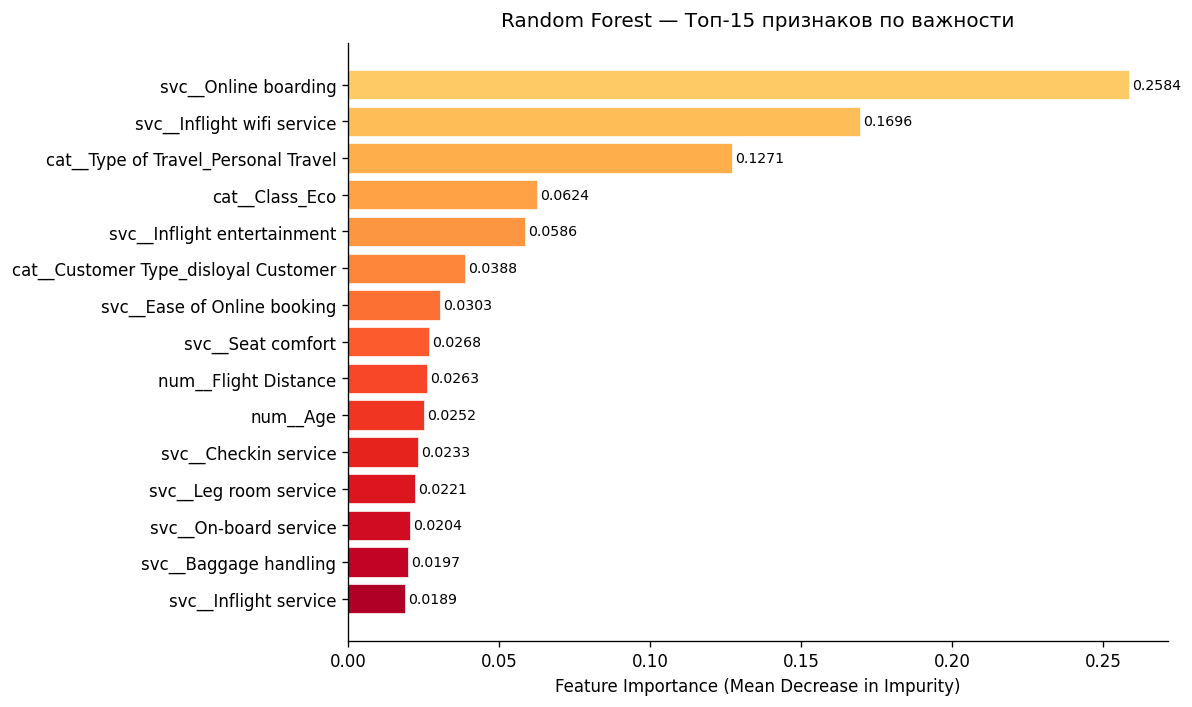

In [7]:
top15_rf = rf_imp_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15_rf['Feature'][::-1],
    top15_rf['Importance'][::-1],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, 15))[::-1],
    edgecolor='white', linewidth=0.4
)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
            f'{w:.4f}', va='center', fontsize=8.5)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=10)
ax.set_title('Random Forest — Топ-15 признаков по важности', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
LightGBM Classifier + RandomizedSearchCV


| Параметр | Роль |
|---|---|
| `n_estimators` | число итераций бустинга |
| `learning_rate` | шаг градиентного спуска |
| `num_leaves` | сложность дерева (главный параметр LGBM) |
| `max_depth` | ограничение глубины против переобучения |
| `subsample` | доля строк на итерацию (stochastic boosting) |
| `colsample_bytree` | доля признаков на дерево |
| `reg_alpha / reg_lambda` | L1 / L2 регуляризация листьев |

In [8]:
lgbm_param_dist = {
    'classifier__n_estimators':    randint(200, 1001),
    'classifier__learning_rate':   loguniform(0.01, 0.3),
    'classifier__num_leaves':      randint(20, 150),
    'classifier__max_depth':       [-1, 5, 7, 10, 12, 15],
    'classifier__min_child_samples': randint(10, 60),
    'classifier__subsample':       uniform(0.6, 0.4),    
    'classifier__colsample_bytree': uniform(0.5, 0.5),
    'classifier__reg_alpha':       loguniform(1e-4, 1.0),
    'classifier__reg_lambda':      loguniform(1e-4, 1.0),
    'classifier__class_weight':    ['balanced', None]
}

lgbm_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', LGBMClassifier(
        objective='binary',
        metric='auc',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1       
    ))
])

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=20,           
    scoring='roc_auc',
    cv=skf,
    refit=True,
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)

t0 = time.time()
lgbm_search.fit(X_train, y_train)
lgbm_time = time.time() - t0

print(f"\nЛучшие гиперпараметры LightGBM:")
for k, v in lgbm_search.best_params_.items():
    print(f"  {k.replace('classifier__',''):30s}: {v:.4f}" if isinstance(v, float) else
          f"  {k.replace('classifier__',''):30s}: {v}")
print(f"\n  Best CV ROC-AUC : {lgbm_search.best_score_:.4f}")


Лучшие гиперпараметры LightGBM:
  class_weight                  : balanced
  colsample_bytree              : 0.6424
  learning_rate                 : 0.0113
  max_depth                     : -1
  min_child_samples             : 11
  n_estimators                  : 841
  num_leaves                    : 73
  reg_alpha                     : 0.0001
  reg_lambda                    : 0.0024
  subsample                     : 0.8537

  Best CV ROC-AUC : 0.9955


In [9]:
lgbm_best  = lgbm_search.best_estimator_
lgbm_pred  = lgbm_best.predict(X_test)
lgbm_proba = lgbm_best.predict_proba(X_test)[:, 1]

results.append(compute_metrics('LightGBM (tuned)', y_test, lgbm_pred, lgbm_proba))

print("LightGBM Test Metrics (после оптимизации):")
for k, v in results[-1].items():
    if k != 'Model': print(f"  {k:12s}: {v}")

lgbm_clf    = lgbm_best.named_steps['classifier']
lgbm_imp_df = pd.DataFrame({
    'Feature':    lgbm_best.named_steps['preprocessor'].get_feature_names_out(),
    'Gain':       lgbm_clf.booster_.feature_importance(importance_type='gain'),
    'Split':      lgbm_clf.booster_.feature_importance(importance_type='split')
}).sort_values('Gain', ascending=False)

print(f"\nТоп-10 признаков (LightGBM — gain importance):")
print(lgbm_imp_df.head(10).to_string(index=False))

LightGBM Test Metrics (после оптимизации):
  Accuracy    : 0.965
  F1-Score    : 0.9597
  ROC-AUC     : 0.9956
  Precision   : 0.9708
  Recall      : 0.9489

Топ-10 признаков (LightGBM — gain importance):
                             Feature         Gain  Split
                svc__Online boarding 1.597551e+06   2829
          svc__Inflight wifi service 1.157435e+06   5428
 cat__Type of Travel_Personal Travel 6.606608e+05   1029
         svc__Inflight entertainment 3.048053e+05   2892
                      cat__Class_Eco 2.449047e+05   1876
cat__Customer Type_disloyal Customer 2.213242e+05   1384
         svc__Ease of Online booking 1.542109e+05   2706
               svc__Baggage handling 1.488676e+05   3469
                   svc__Seat comfort 1.440854e+05   2835
                svc__Checkin service 1.367758e+05   2269


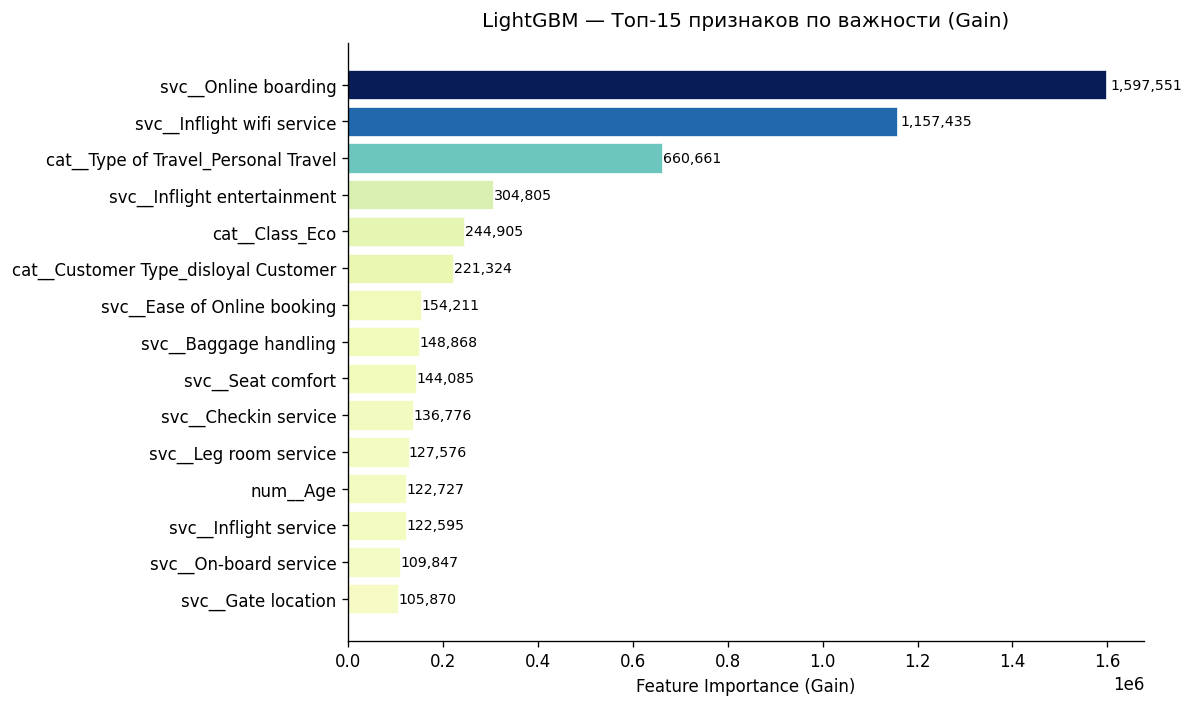

In [10]:
top15_lgbm = lgbm_imp_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
gain_norm = top15_lgbm['Gain'] / top15_lgbm['Gain'].max()
colors_lgbm = plt.cm.YlGnBu(gain_norm[::-1])
bars = ax.barh(
    top15_lgbm['Feature'][::-1],
    top15_lgbm['Gain'][::-1],
    color=colors_lgbm, edgecolor='white', linewidth=0.4
)
for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.005, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Feature Importance (Gain)', fontsize=10)
ax.set_title('LightGBM — Топ-15 признаков по важности (Gain)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
 сравнительная таблица: LogReg vs RF vs LightGBM

In [11]:
comparison_df = pd.DataFrame(results).set_index('Model')

print("  ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")

styled = (comparison_df.style
    .background_gradient(cmap='RdYlGn', vmin=0.75, vmax=1.0)
    .highlight_max(color='#27ae60', props='font-weight: bold')
    .format('{:.4f}')
    .set_caption('Сравнение моделей на тестовой выборке ( больше — лучше)')
)

display(styled)

baseline = comparison_df.iloc[0]
delta_df = comparison_df.iloc[1:] - baseline
delta_df.index = [m + ' Δ vs Baseline' for m in delta_df.index.str.replace(' \\(tuned\\)', '', regex=True)]

print("\nПрирост метрик относительно Baseline (LogReg L1):")
display(delta_df.style
    .background_gradient(cmap='RdYlGn', vmin=-0.05, vmax=0.1)
    .format(lambda v: f"+{v:.4f}" if v >= 0 else f"{v:.4f}")
)

  ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ


,Accuracy,F1-Score,ROC-AUC,Precision,Recall
Model,,,,,
LogReg (L1) — Baseline,0.8664,0.8489,0.9257,0.8428,0.8551
Random Forest (tuned),0.9640,0.9584,0.9947,0.9730,0.9442
LightGBM (tuned),0.9650,0.9597,0.9956,0.9708,0.9489



Прирост метрик относительно Baseline (LogReg L1):


,Accuracy,F1-Score,ROC-AUC,Precision,Recall
Random Forest Δ vs Baseline,+0.0976,+0.1095,+0.0690,+0.1302,+0.0891
LightGBM Δ vs Baseline,+0.0986,+0.1108,+0.0699,+0.1280,+0.0938


---
Визуальное сравнение: метрики, ROC-кривые, Confusion Matrices

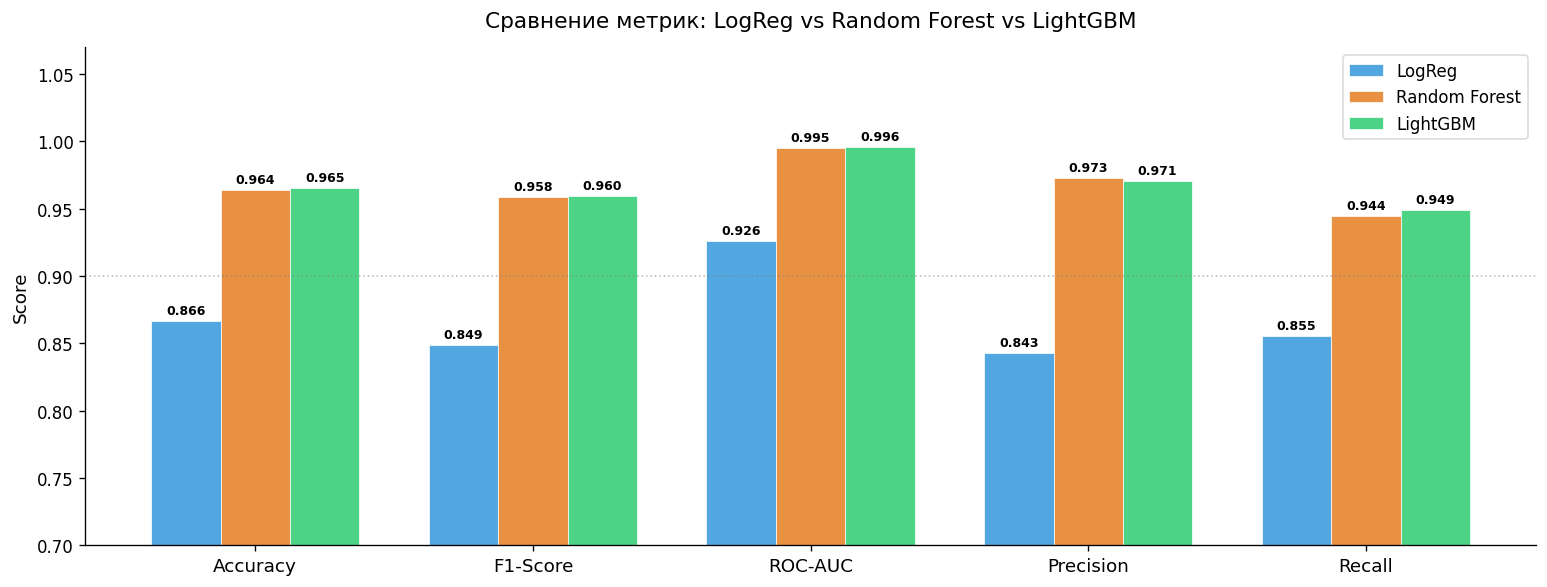

In [12]:
metrics      = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall']
model_names  = [r['Model'].split(' (')[0].replace(' — Baseline','') for r in results]
palette      = ['#3498db', '#e67e22', '#2ecc71']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color) in enumerate(zip(results, palette)):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model_names[i],
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.70, 1.07)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Сравнение метрик: LogReg vs Random Forest vs LightGBM', fontsize=13, pad=12)
ax.legend(fontsize=10, framealpha=0.7)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

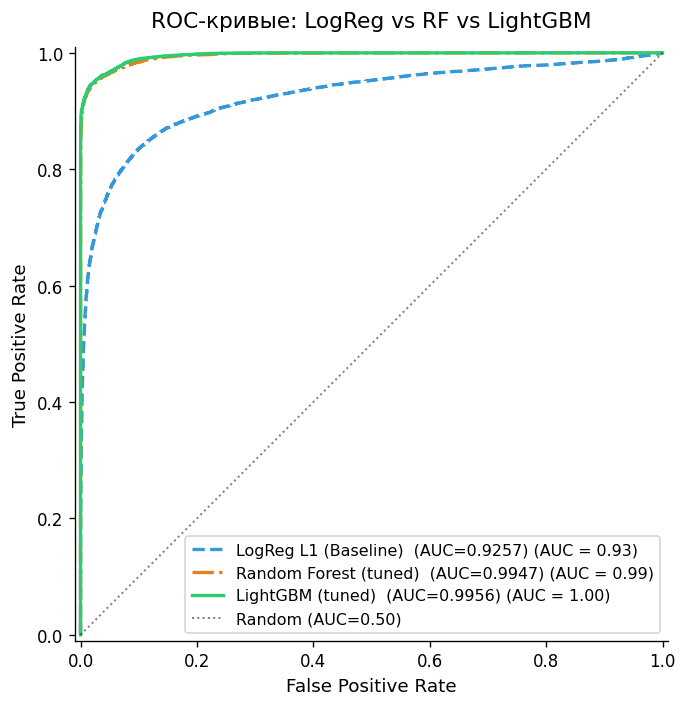

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

model_data = [
    ('LogReg L1 (Baseline)', lr_proba,   '#3498db', '--'),
    ('Random Forest (tuned)', rf_proba,  '#e67e22', '-.'),
    ('LightGBM (tuned)',      lgbm_proba,'#2ecc71', '-' )
]

for name, proba, color, ls in model_data:
    auc = roc_auc_score(y_test, proba)
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=f'{name}  (AUC={auc:.4f})',
        ax=ax, color=color, linestyle=ls, linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k:', lw=1.2, alpha=0.5, label='Random (AUC=0.50)')
ax.set_title('ROC-кривые: LogReg vs RF vs LightGBM', fontsize=13, pad=12)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=9.5, loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

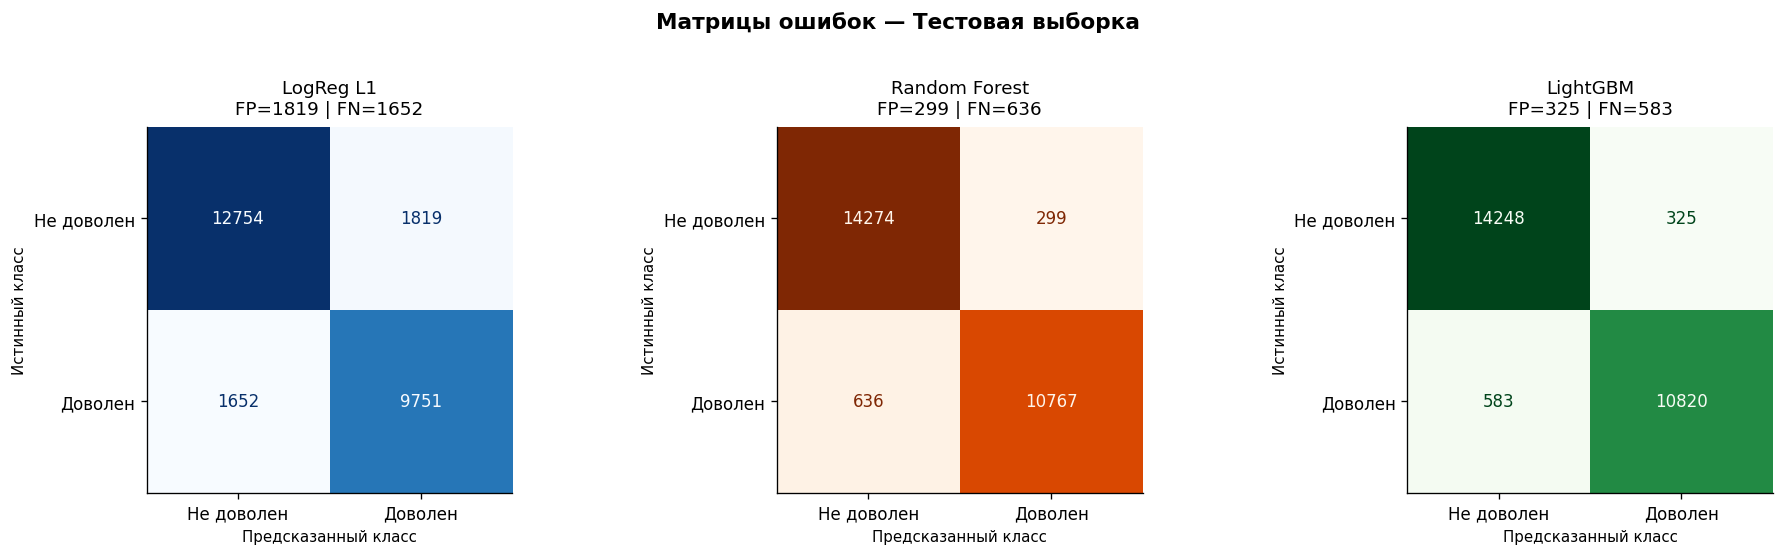

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, pred, color) in zip(axes, [
    ('LogReg L1',    lr_pred,   'Blues'),
    ('Random Forest', rf_pred,  'Oranges'),
    ('LightGBM',     lgbm_pred, 'Greens')
]):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Не доволен', 'Доволен']
    )
    disp.plot(cmap=color, ax=ax, colorbar=False, values_format='d')
    ax.set_title(f'{name}\nFP={fp} | FN={fn}', fontsize=11, pad=8)
    ax.set_xlabel('Предсказанный класс', fontsize=9)
    ax.set_ylabel('Истинный класс', fontsize=9)

plt.suptitle('Матрицы ошибок — Тестовая выборка', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()

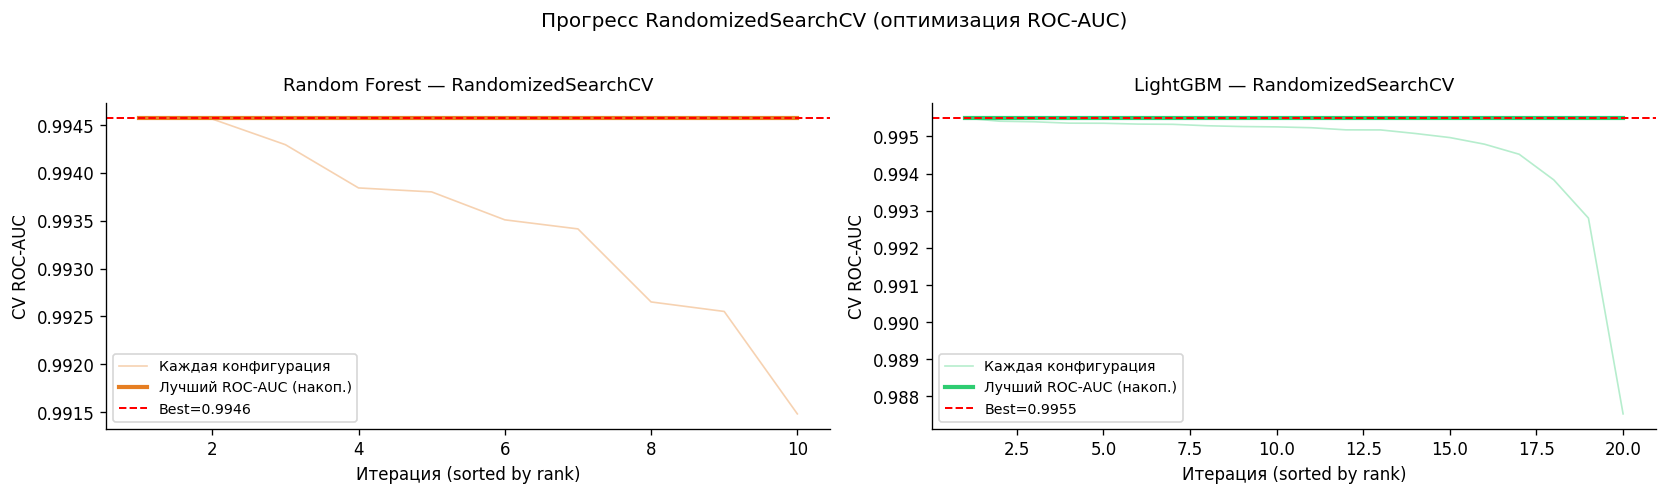

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (search, title, color) in zip(axes, [
    (rf_search,   'Random Forest',   '#e67e22'),
    (lgbm_search, 'LightGBM',        '#2ecc71')
]):
    cv_res = pd.DataFrame(search.cv_results_)
    scores = cv_res.sort_values('rank_test_score')['mean_test_score'].values
    cummax = np.maximum.accumulate(scores)  

    ax.plot(range(1, len(scores)+1), scores,
            color=color, alpha=0.35, linewidth=1, label='Каждая конфигурация')
    ax.plot(range(1, len(scores)+1), cummax,
            color=color, linewidth=2.5, label='Лучший ROC-AUC (накоп.)')
    ax.axhline(search.best_score_, color='red', linestyle='--',
               linewidth=1.2, label=f'Best={search.best_score_:.4f}')
    ax.set_title(f'{title} — RandomizedSearchCV', fontsize=11, pad=8)
    ax.set_xlabel('Итерация (sorted by rank)', fontsize=10)
    ax.set_ylabel('CV ROC-AUC', fontsize=10)
    ax.legend(fontsize=8.5)

plt.suptitle('Прогресс RandomizedSearchCV (оптимизация ROC-AUC)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('hyperparameter_search_progress.png', dpi=150, bbox_inches='tight')
plt.show()

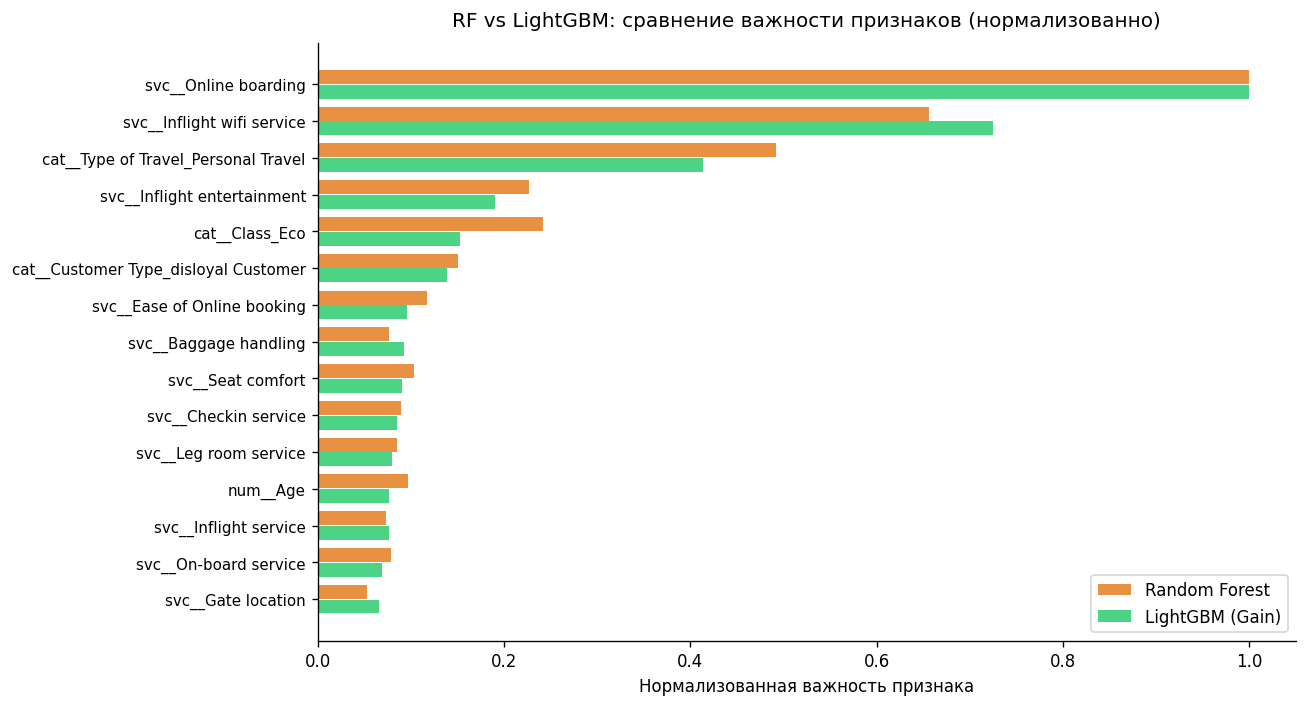

In [16]:
common_features = set(rf_imp_df['Feature'].head(15)) | set(lgbm_imp_df['Feature'].head(15))

rf_imp_norm   = rf_imp_df.set_index('Feature')['Importance'] / rf_imp_df['Importance'].max()
lgbm_imp_norm = lgbm_imp_df.set_index('Feature')['Gain']     / lgbm_imp_df['Gain'].max()

compare_imp = pd.DataFrame({
    'Random Forest (norm)': rf_imp_norm,
    'LightGBM Gain (norm)': lgbm_imp_norm
}).dropna().sort_values('LightGBM Gain (norm)', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
x_idx = np.arange(len(compare_imp))
ax.barh(x_idx + 0.2, compare_imp['Random Forest (norm)'][::-1],
        0.38, label='Random Forest', color='#e67e22', alpha=0.85)
ax.barh(x_idx - 0.2, compare_imp['LightGBM Gain (norm)'][::-1],
        0.38, label='LightGBM (Gain)', color='#2ecc71', alpha=0.85)
ax.set_yticks(x_idx)
ax.set_yticklabels(compare_imp.index[::-1], fontsize=9)
ax.set_xlabel('Нормализованная важность признака', fontsize=10)
ax.set_title('RF vs LightGBM: сравнение важности признаков (нормализованно)', fontsize=12, pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
 Финальная таблица с информацией о поиске

In [17]:
final_summary = pd.DataFrame([
    {
        'Модель':         'LogReg (L1) — Baseline',
        'Метод поиска':   'Фиксированные параметры',
        'n_iter / folds': '— / 5',
        'Best CV AUC':    '—',
        'Test F1':        results[0]['F1-Score'],
        'Test ROC-AUC':   results[0]['ROC-AUC'],
        'Test Accuracy':  results[0]['Accuracy'],
    },
    {
        'Модель':         'Random Forest (tuned)',
        'Метод поиска':   'RandomizedSearchCV',
        'n_iter / folds': f'30 / 5',
        'Best CV AUC':    round(rf_search.best_score_, 4),
        'Test F1':        results[1]['F1-Score'],
        'Test ROC-AUC':   results[1]['ROC-AUC'],
        'Test Accuracy':  results[1]['Accuracy'],
    },
    {
        'Модель':         'LightGBM (tuned)',
        'Метод поиска':   'RandomizedSearchCV',
        'n_iter / folds': f'40 / 5',
        'Best CV AUC':    round(lgbm_search.best_score_, 4),
        'Test F1':        results[2]['F1-Score'],
        'Test ROC-AUC':   results[2]['ROC-AUC'],
        'Test Accuracy':  results[2]['Accuracy'],
    },
]).set_index('Модель')

display(final_summary.style
    .highlight_max(subset=['Test F1', 'Test ROC-AUC', 'Test Accuracy'],
                   props='background-color: #d5f5e3; font-weight: bold;')
    .set_caption('зелёным выделено лучшее значение каждой метрики')
)

,Метод поиска,n_iter / folds,Best CV AUC,Test F1,Test ROC-AUC,Test Accuracy
Модель,,,,,,
LogReg (L1) — Baseline,Фиксированные параметры,— / 5,—,0.848900,0.925700,0.866400
Random Forest (tuned),RandomizedSearchCV,30 / 5,0.994600,0.958400,0.994700,0.964000
LightGBM (tuned),RandomizedSearchCV,40 / 5,0.995500,0.959700,0.995600,0.965000
